# Pancreas 数据集benchmark整合

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import funkyheatmappy

import cafe

img_dir = "./img/25.12.24-benchmark_summary"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

## 2. Merge benchmark metrics and metadata for pancreas dataset

preprocess benchmark dataframe: normalize metric, add method metadata.

In [ ]:
method_metadata_df = pd.read_csv("method_metadata.csv", dtype="str", index_col=0)

benchmark_df = pd.read_csv("pancreas_benchmark_df.csv", index_col=0) # TODO: 用多个数据集.cafe/.../benchmark/benchmark.summary的平均值替换
benchmark_df.loc["ti_slingshot", "type"] = "Directed"


benchmark_df.index = benchmark_df["id"]
benchmark_df =benchmark_df.merge(method_metadata_df, left_index=True, right_index=True, how="left")
# benchmark_df["wrapper_type"] = benchmark_df["type"].fillna("unknown")

# 
group_list = ["Velocity", "Lineage", "Linear", "Directed", "Cluster"]
benchmark_df["wrapper_type"] = pd.Categorical(benchmark_df["wrapper_type"], categories=group_list)
benchmark_df = benchmark_df.sort_values(by="overall", ascending=False)
benchmark_df = benchmark_df.sort_values(by="wrapper_type")

benchmark_df

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,prior_level,time,time_text,memory,memory_text,overall,level,citations,stars,wrapper_type
id,,,,,,,,,,,,,,,,,,,,,
velovi,0.995,0.780,0.921,1.0,1.000,0.961,0.882,1.000,1.000,1.000,...,free,331.190,6min,2329.13,2G,0.929,free,97,40,NaN
scvelo,0.995,0.769,0.894,1.0,1.000,0.961,0.882,1.000,1.000,1.000,...,free,14.000,14s,920.62,921M,0.926,free,2605,467,NaN
pyrovelocity,0.915,0.572,0.784,0.0,0.750,0.528,0.838,0.801,0.944,0.998,...,free,672.870,11min,14051.57,14G,0.686,free,23,47,NaN
dynamo,0.538,0.764,0.886,0.0,0.500,0.560,0.779,0.775,0.941,0.989,...,strong restricted,125.330,2min,5503.20,5G,0.650,strong restricted,385,472,NaN
unitvelo,0.846,0.745,0.952,0.0,0.500,0.341,0.799,0.715,0.920,0.995,...,strong restricted,482.830,8min,3624.93,4G,0.626,strong restricted,NaN,26,NaN
veloae,0.484,0.410,0.918,0.0,0.500,0.574,0.789,0.923,0.932,0.997,...,free,37.120,37s,2283.07,2G,0.569,free,57,28,NaN
ti_slingshot,0.987,0.734,0.897,0.0,0.000,0.267,0.500,0.429,0.479,0.854,...,weakly restricted,67.777,1min,1145.19,1G,0.537,weakly restricted,NaN,NaN,NaN
palantir,0.991,0.687,1.000,0.0,0.000,0.267,0.674,0.189,0.272,0.891,...,strong restricted,0.000,0s,0.00,0M,0.431,strong restricted,674,267,NaN
comp1,0.950,0.678,1.000,0.0,0.000,0.267,0.500,0.189,0.281,0.852,...,weakly restricted,0.000,0s,0.00,0M,0.425,weakly restricted,NaN,NaN,NaN


No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:metric_palette, meta_palette, resource_palette, white6black4, overall_palette
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True, 'geom': 'funkyrect'} did not contain labels, inferring from the geom.
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1']} did not contain size, inferring from the labels.
Legend {'title': 'metric_palette', 'palette': 'metric_palette', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9,

<Figure size 1800x1200 with 0 Axes>

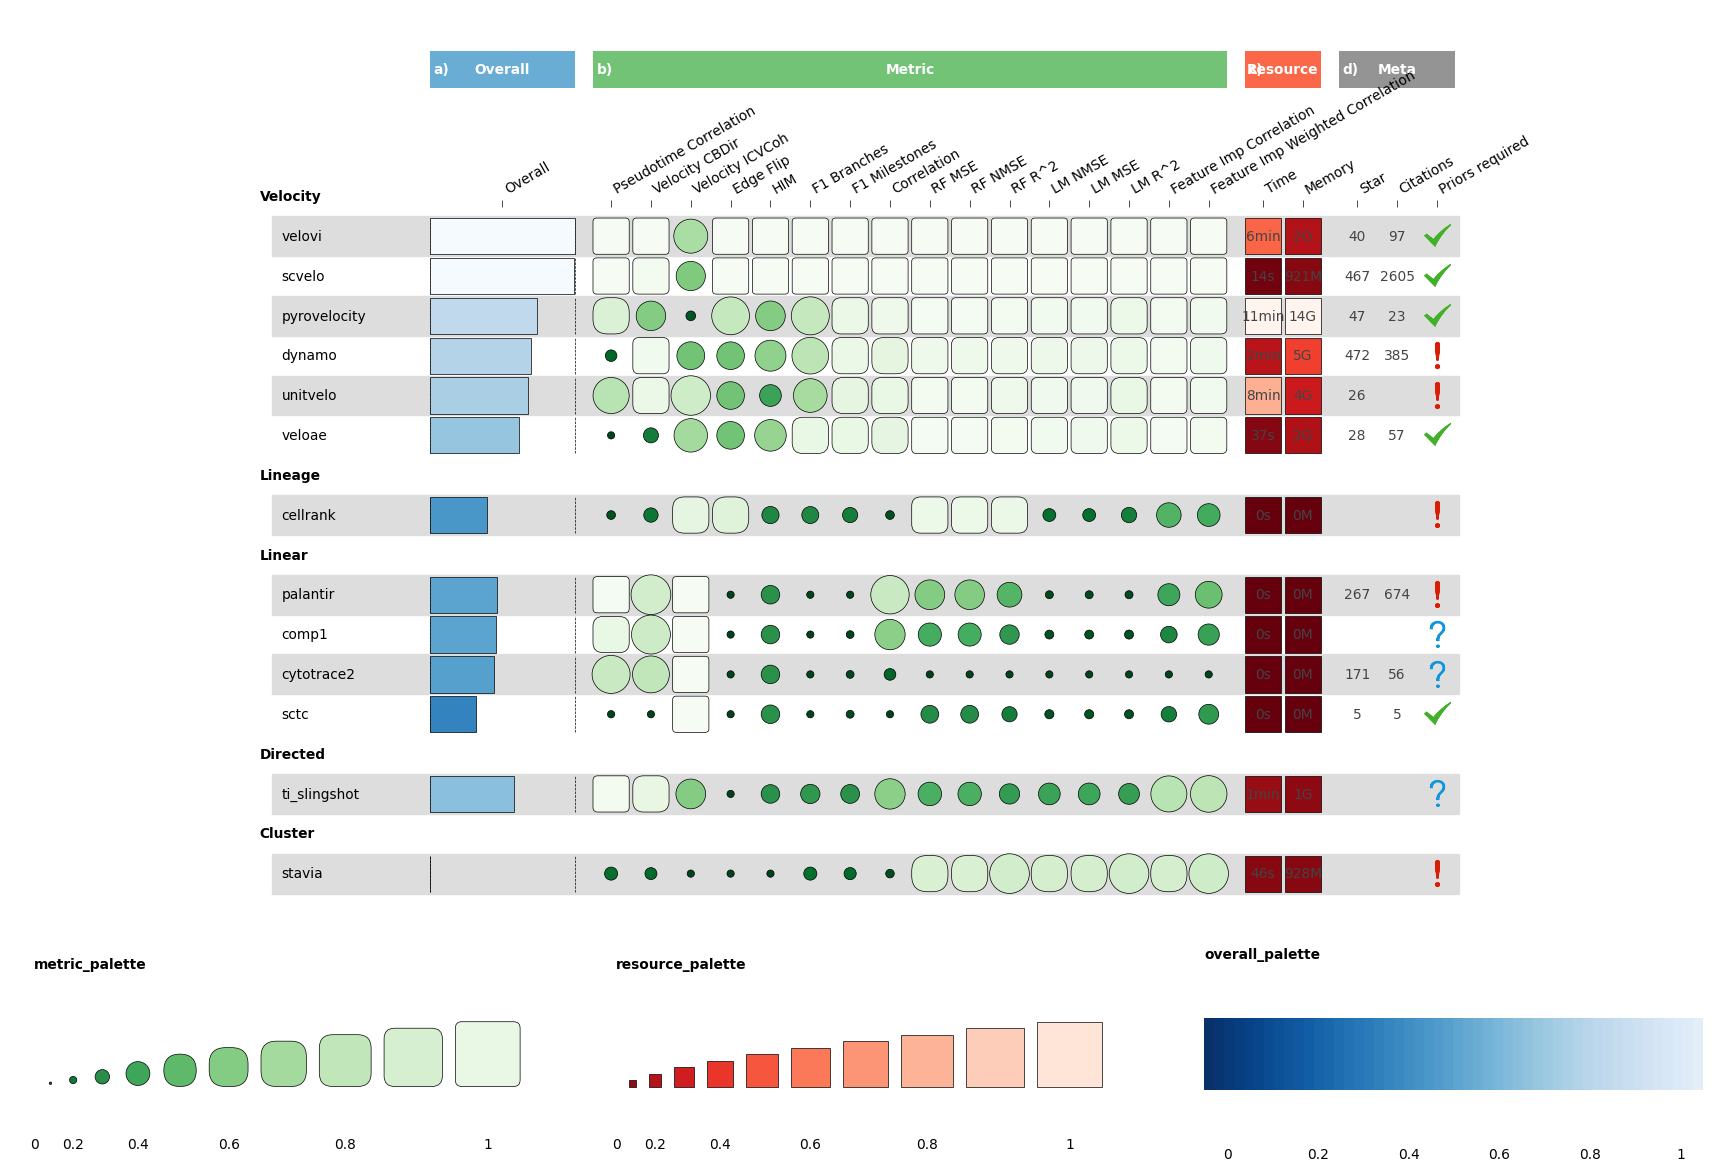

In [ ]:
plt.figure(figsize=(18, 12))

# 样式参考dynbenchmark: https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html
column_list = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 4}, np.nan],
    # ["type", np.nan, "Wrapper Type", "text", {"ha": 0, "width": 4}, np.nan],
    # ["prior_level", "overall", "Priors required", "text", {}, np.nan], # move to metadata
]


if "overall" in benchmark_df.columns:
    column_list.append(["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "overall_palette"])

# accuracy metrics
id2name = {
    "pseudotime_correlation": "Pseudotime Correlation",
    "velocity_cbdir": "Velocity CBDir",
    "velocity_icvcoh": "Velocity ICVCoh",
    "edge_flip": "Edge Flip",
    "him": "HIM",
    # "isomorphic": "Isomorphic",
    "F1_branches": "F1 Branches",
    "F1_milestones": "F1 Milestones",
    "correlation": "Correlation",
    "rf_mse": "RF MSE",
    "rf_nmse": "RF NMSE",
    "rf_rsq": "RF R^2",
    "lm_nmse": "LM NMSE",
    "lm_mse": "LM MSE",
    "lm_rsq": "LM R^2",
    "featureimp_cor": "Feature Imp Correlation",
    "featureimp_wcor": "Feature Imp Weighted Correlation",
}

metric_column_list = []
for id, name in id2name.items():
    if id in benchmark_df.columns:
        metric_column_list.append([id, "metric", name, "funkyrect", "options", "metric_palette"])
column_list = column_list[:4] + metric_column_list + column_list[4:]

# resource group

if "time" in benchmark_df.columns:
    column_list.append(["time", "resource", "Time", "rect", "scaling", "resource_palette"])
    column_list.append(["time_text", "resource", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"])

if "memory" in benchmark_df.columns:
    column_list.append(["memory", "resource", "Memory", "rect", "scaling", "resource_palette"])
    column_list.append(["memory_text", "resource", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"]) # only show black here, need mannly adjust

# metadata group
column_list.append(["stars", "meta", "Star", "text", {}, "white6black4"])
column_list.append(["citations", "meta", "Citations", "text", {}, "white6black4"])
column_list.append(["prior_level", "meta", "Priors required", "text", {"size":0.3, "scale": True} , "meta_palette"])


column_info = pd.DataFrame(column_list[1:], columns=column_list[0])
column_info.index = column_info["id"]

# set 
column_info.loc["prior_level", "path"] = "img/funkeyheatmap/"
column_info.loc["prior_level", "filetype"] = "png"
column_info.loc["prior_level", "geom"] = "image"

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[
        ["Overall", "overall", "overall_palette"],
          ["Metric", "metric", "metric_palette"],
          ["Resource", "resource", "resource_palette"],
          ["Meta", "meta", "meta_palette"]
          ]
)

# Define row groups (order matters)
# group_list = ["Linear", "Cluster", "Velocity", "Lineage", "Directed"]
# group_list = ["Velocity", "Lineage", "Linear", "Directed", "Cluster"] # use previous group list
row_groups = pd.DataFrame({"group": group_list, "Group": group_list})

# Row annotation and grouping
row_info = benchmark_df[["type"]].rename(columns={"type": "group"})
row_info["id"] = row_info.index  # Ensure 'id' column exists for the text column in visualization
row_info["group"] = pd.Categorical(row_info["group"], categories=group_list, ordered=True)
row_info = row_info.sort_values("group")

# sort benchmark_df according to row_info
benchmark_df = benchmark_df.loc[row_info.index]

# palette definitions
palettes = {
    "overall_palette": "Blues",
    "metric_palette": "Greens",
    "resource_palette": "Reds",
    "meta_palette": "Greys",
}

# legends
# legends = [
#     {"palette": "overall_palette", "enabled": False},
#     {"palette": "meta_palette", "enabled": True, "title": "Priors required", "size": 10}
# ]


funkyheatmappy.funky_heatmap(
    benchmark_df,
    column_info=column_info, 
    column_groups=column_groups,
    row_info=row_info,
    row_groups=row_groups,
    palettes=palettes,
    # legends=legends,
)

plt.savefig("./img/25.12.24-benchmark_summary/benchmark_summary_pancreas.pdf")

## 3. Show trajectory result

In [ ]:
fadata = cafe.data.read_pancreas()
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
# model_name_list = benchmark_df.index.tolist()[1:3]
# sc_pl_embedding_kwargs = {
#     "legend_loc": None,
# }

# n = len(model_name_list)
# fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

# for i in range(n):
#     model_name = model_name_list[i]
#     axes[i, 0].set_title(model_name_list[i])
#     fadata.load_trajectory_dict(model_name)
#     cafe.plot.plot_trajectory(fadata, model_name=model_name, **sc_pl_embedding_kwargs)
#     cafe.plot.plot_graph(fadata, model_name=model_name, **sc_pl_embedding_kwargs)
#     cafe.plot.plot_wrapper(fadata, model_name=model_name, mode="stream")
#     # axes[i, 0] = cafe.plot.plot_trajectory(fadata, model_name=model_name, save=f"{img_dir}/trajectory_{model_name}.png", **sc_pl_embedding_kwargs)
#     # axes[i, 1] = cafe.plot.plot_graph(fadata, model_name=model_name, save=f"{img_dir}/graph_{model_name}.png", **sc_pl_embedding_kwargs)
#     # cafe.plot.plot_wrapper(fadata, model_name=model_name, mode="stream", save=f"{img_dir}/wrapper_{model_name}.png")

cannot import name 'VectorPlotter' from 'seaborn._core' (/root/miniconda3/envs/cafe/lib/python3.10/site-packages/seaborn/_core/__init__.py)


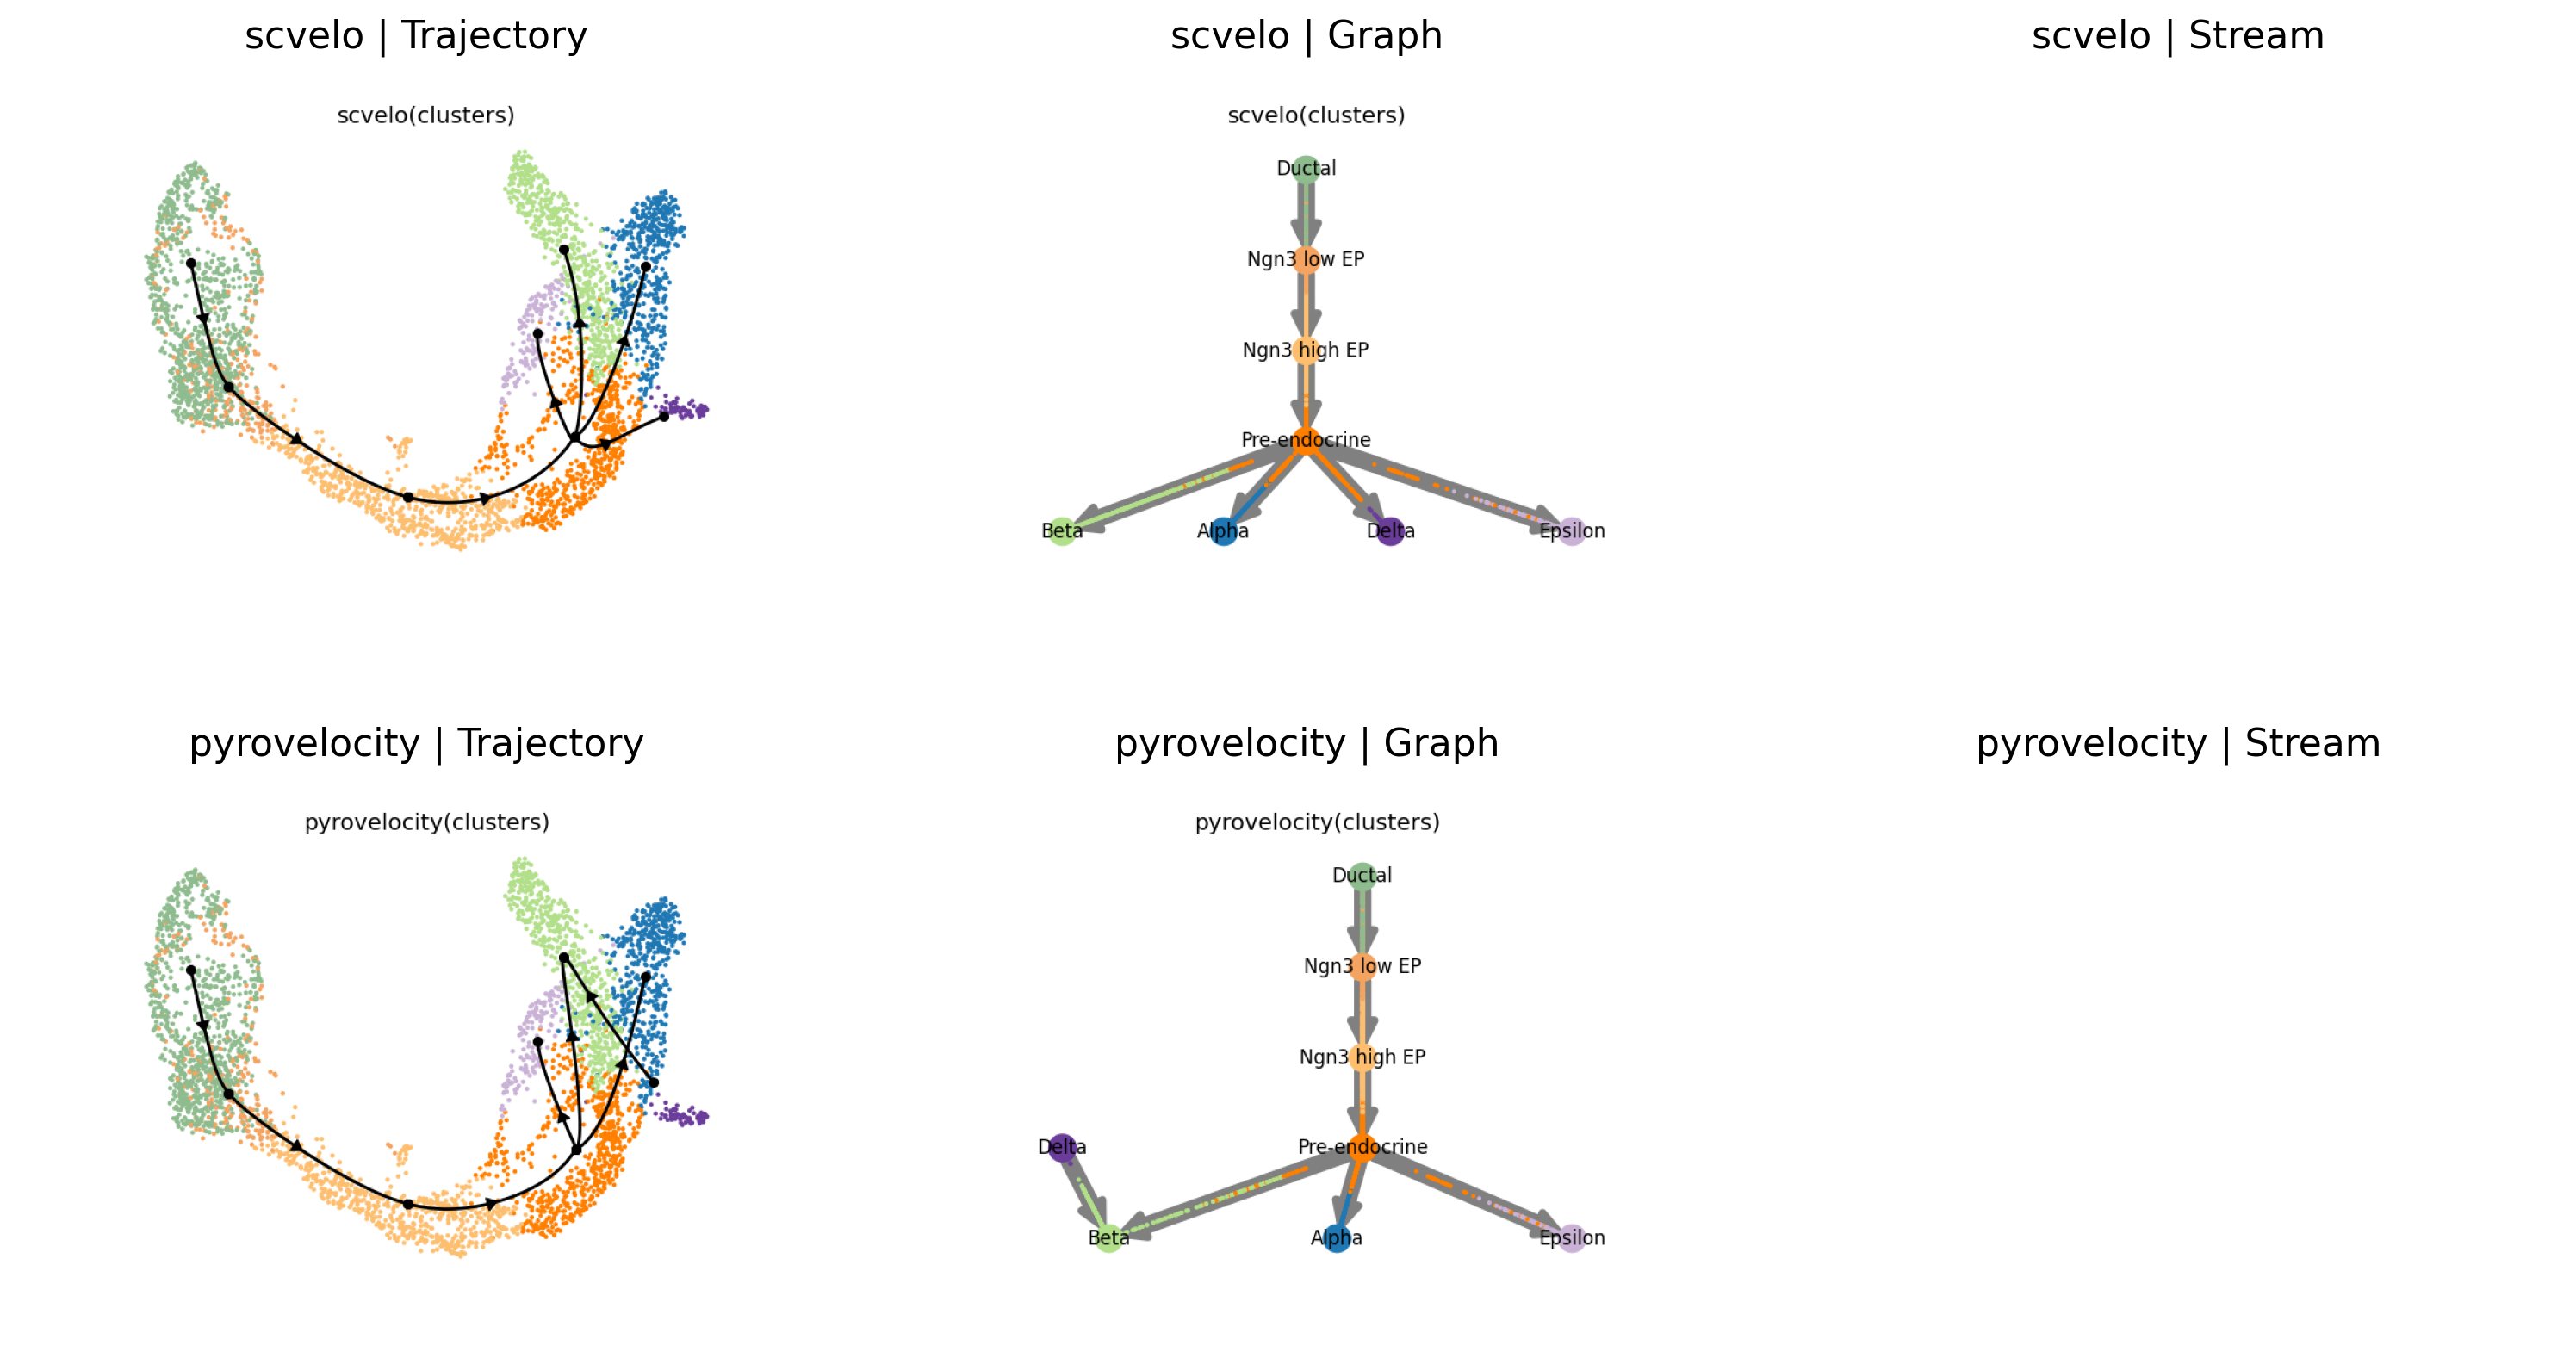

<Figure size 640x480 with 0 Axes>

In [ ]:
import patchworklib as pw
from IPython.utils.capture import capture_output

model_name_list = benchmark_df.index.tolist()[1:3]
sc_pl_embedding_kwargs = {
    "legend_loc": None,
}


def _extract_first_ax(obj):
    """从 plot 返回值中尽可能提取一个 matplotlib Axes。"""
    if obj is None:
        return None
    if hasattr(obj, "plot") and hasattr(obj, "figure"):
        return obj
    if isinstance(obj, np.ndarray):
        if obj.size == 0:
            return None
        return _extract_first_ax(obj.flat[0])
    if isinstance(obj, (list, tuple)):
        if len(obj) == 0:
            return None
        return _extract_first_ax(obj[0])
    return None


def _fig_score(fig):
    """给 figure 打分，优先选择真正有绘图内容的图。"""
    if fig is None:
        return (-1, -1)

    axes = fig.axes
    n_axes = len(axes)
    artist_score = 0

    for ax in axes:
        artist_score += len(ax.lines)
        artist_score += len(ax.collections)
        artist_score += len(ax.patches)
        artist_score += len(ax.images)
        artist_score += len(ax.texts)

    return (n_axes, artist_score)


def _pick_best_figure(fig_list):
    if len(fig_list) == 0:
        return None
    return max(fig_list, key=_fig_score)


def _fig_to_rgb_array(fig):
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    return img.reshape(h, w, 3)


def _make_image_brick(img, title, figsize=(4.2, 3.2)):
    br = pw.Brick(figsize=figsize)
    br.imshow(img)
    br.set_title(title)
    br.set_axis_off()
    return br


def _render_call_to_image(plot_call):
    """执行绘图并抓取最合适的 figure 转为图片。"""
    before_nums = set(plt.get_fignums())

    with capture_output():
        ret = plot_call()

    after_nums = set(plt.get_fignums())
    new_nums = [n for n in after_nums if n not in before_nums]
    new_figs = [plt.figure(n) for n in new_nums]

    ax = _extract_first_ax(ret)
    if ax is not None and hasattr(ax, "figure"):
        target_fig = ax.figure
    else:
        target_fig = _pick_best_figure(new_figs)

    # 极端情况下如果没有新图，回退到当前 figure
    if target_fig is None:
        target_fig = plt.gcf()

    img = _fig_to_rgb_array(target_fig)

    # 仅关闭本次调用新创建的 figure，避免影响前序单元状态
    for fig in new_figs:
        plt.close(fig)

    return img


pw_rows = []

for model_name in model_name_list:
    fadata.load_trajectory_dict(model_name)

    img_traj = _render_call_to_image(
        lambda: cafe.plot.plot_trajectory(
            fadata,
            model_name=model_name,
            **sc_pl_embedding_kwargs,
        )
    )

    img_graph = _render_call_to_image(
        lambda: cafe.plot.plot_graph(
            fadata,
            model_name=model_name,
            **sc_pl_embedding_kwargs,
        )
    )

    # wrapper 可能不返回 ax，这里通过 figure 打分自动选中含 stream 内容的图
    img_wrapper = _render_call_to_image(
        lambda: cafe.plot.plot_wrapper(
            fadata,
            model_name=model_name,
            mode="stream",
        )
    )

    br_traj = _make_image_brick(img_traj, f"{model_name} | Trajectory")
    br_graph = _make_image_brick(img_graph, f"{model_name} | Graph")
    br_wrapper = _make_image_brick(img_wrapper, f"{model_name} | Stream")

    pw_rows.append(br_traj | br_graph | br_wrapper)

if len(pw_rows) == 0:
    raise ValueError("model_name_list 为空，无法拼图")

final_pw = pw_rows[0]
for row in pw_rows[1:]:
    final_pw = final_pw / row

out_file = f"{img_dir}/trajectory_grid_patchworklib.png"
final_pw.savefig(out_file, dpi=220)

from IPython.display import Image, display

display(Image(filename=out_file))
final_pw